# VQC Based on IQC:AIL

## Imports

In [18]:
import os

import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.stats import unitary_group
from scipy.linalg import expm as expMatrix
import scipy.linalg
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.datasets import make_moons
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd


## Parâmetros

In [12]:
RANDOM_SEED = 1
N_SAMPLES = 5000
N_PRINTINGS = 1
N_SHOTS=2048

In [94]:
import numpy as np
from scipy.stats import unitary_group, kstest

def is_unitary(U):
    """Check if a matrix is unitary."""
    return np.allclose(U.conj().T @ U, np.eye(U.shape[0]))

def check_isotropy(U):
    """Check isotropy of rows and columns."""
    row_norms = np.linalg.norm(U, axis=1)
    col_norms = np.linalg.norm(U, axis=0)
    return np.allclose(row_norms, row_norms[0]) and np.allclose(col_norms, col_norms[0])

def analyze_distribution(U):
    """Check if entries follow Gaussian distribution."""
    real_parts = U.real.flatten()
    imag_parts = U.imag.flatten()
    _, real_pval = kstest(real_parts, 'norm')
    _, imag_pval = kstest(imag_parts, 'norm')
    return real_pval > 0.05 and imag_pval > 0.05

# Example matrix
N_features=2
N_qubits=math.ceil(np.log2(N_features)+1)
X=np.random.rand(N_features)
X_new=np.append(X,X)
U = np.matrix(unitary_group.rvs(2**N_qubits))
np.fill_diagonal(U,X_new)
# Check properties
if is_unitary(U):
    print("Matrix is unitary.")
    print("Isotropy:", check_isotropy(U))
    print("Gaussian distribution:", analyze_distribution(U))
else:
    print("Matrix is not unitary.")

import numpy as np

def gram_schmidt_columns(matrix):
    """
    Apply the Gram-Schmidt process to the columns of a given matrix to produce
    an orthonormal set of vectors.

    Parameters:
        matrix (numpy.ndarray): Input matrix of shape (m, n), where m >= n.

    Returns:
        numpy.ndarray: Matrix with orthonormal columns.
    """
    m, n = matrix.shape
    if m < n:
        raise ValueError("The number of rows must be greater than or equal to the number of columns.")

    # Create an empty matrix to store orthonormal vectors
    Q = np.zeros(2**N_qubits)
    Q = np.diag(Q)

    for i in range(n):
        # Start with the current column
        v = matrix[:][i]

        # Subtract projections of v onto previous vectors in Q
        for j in range(i):
            v -= np.dot(Q[:, j], matrix[:, i]) * Q[:, j]

        # Normalize the vector
        norm = np.linalg.norm(v)
        if norm == 0:
            raise ValueError("The input matrix has linearly dependent columns.")
        Q[:, i] = v / norm

    return Q

if is_unitary((gram_schmidt_columns(U))):
    print("Matrix is unitary.")
    print("Isotropy:", check_isotropy(U))
    print("Gaussian distribution:", analyze_distribution(U))
else:
    print("Matrix is not unitary.")

Matrix is not unitary.
Matrix is not unitary.


C:\Users\bito-\AppData\Local\Temp\ipykernel_2376\545869366.py:70: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[:, i] = v / norm


In [58]:
N_features=2
N_qubits=math.ceil(np.log2(N_features)+1)
X_new=np.random.rand(N_features)
U = np.matrix(unitary_group.rvs(2**N_qubits))
print(U)
print()
for i in range(len(U)):
    for j in range(len(U)):
        print(np.sqrt((U[i,j].real)**2+(U[i,j].real)**2))
print()
# Applying X to the diagonal of U
U[:N_features, :N_features] *= np.diag(X_new)  # Multiply the top-left diagonal block
U[N_features:, N_features:] *= np.diag(X_new)  # Multiply the bottom-right diagonal block

print(U)
print()
print(U*U.getH())

[[ 0.2633558 +0.26450028j  0.13657513+0.50348837j  0.71681593+0.07479774j
   0.26199374+0.02166835j]
 [-0.41214212-0.03109167j -0.33699125-0.27639494j  0.18604186-0.20753731j
   0.71994131-0.20788486j]
 [ 0.50830108-0.54732788j -0.42735587+0.35437774j -0.25012342+0.0073404j
   0.26661446-0.01211265j]
 [-0.36252109-0.0222751j  -0.28454502+0.38562539j  0.05549467-0.58069066j
  -0.23275292+0.49391724j]]

0.3724413475605943
0.19314640191551805
1.013730809551195
0.37051509784579095
0.5828569730464851
0.47657759337338207
0.2631029155281709
1.0181507674285593
0.7188462741488808
0.6043724650704575
0.35372793601077673
0.37704978901585545
0.5126822420773282
0.40240742166917165
0.07848131182212026
0.32916234065568845

[[ 0.04995369+0.05017077j  0.06409618+0.23629253j  0.71681593+0.07479774j
   0.26199374+0.02166835j]
 [-0.07817568-0.00589751j -0.15815363-0.12971513j  0.18604186-0.20753731j
   0.71994131-0.20788486j]
 [ 0.50830108-0.54732788j -0.42735587+0.35437774j -0.04744375+0.00139234j
   0.12

## Tratamento do Dataset

In [3]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler() #Normaliza a coluna entre [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normaliza a linha entre [-1,1]
    return data
    
def normalize_iqc(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler() #Normaliza a coluna entre [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
        data = data - 1
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normalize the line between [-1,1]
    return data

## Circuito Teste

In [ ]:
N_features=4
N_QUBITS=math.ceil(np.log2(N_features)+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]

qc = QuantumCircuit(N_QUBITS)
qc.h(QUBITS)

tx = np.random.rand(N_features)
tw = np.random.rand(N_features)
sigmaE = np.diag(tx)*tw.T

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,QUBITS)

display(qc.draw('mpl'))



tqc=transpile(qc, optimization_level=3, basis_gates=["u3", "cx"], seed_transpiler=1)
display(tqc.draw('mpl'))

gate_val = 0
u3_dir = {}
for i, instruction in enumerate(tqc.data):
    if instruction.operation.name == 'u3':
        u3_dir['u3_'+str(gate_val)] = {'qubit':instruction.qubits[0], 'params': instruction.operation.params}
        gate_val +=1
        
print(u3_dir)
print()

gate_val = 0
u3_params = []
for i in range(len(u3_dir)):
    u3_params.append(u3_dir[f'u3_{i}']['params'])

sv=Statevector(qc)
rho=DensityMatrix(sv)

array=np.array(u3_params)/np.pi
plt.plot(array)

plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]
fig,ax=plt.subplots(1,3,figsize=(15,5))

ax[0].hist(array[:,0],label=labels[0],color=colors[0],edgecolor='black')
ax[0].set_xlabel(f'Factor of $\pi$')
ax[0].set_ylabel('Frequency')
ax[0].legend()
ax[0].grid(linestyle='dashed')

ax[1].hist(array[:,1],label=labels[1],color=colors[1],edgecolor='black')
ax[1].set_xlabel(f'Factor of $\pi$')
ax[1].set_ylabel('Frequency')
ax[1].legend()
ax[1].grid(linestyle='dashed')

ax[2].hist(array[:,2],label=labels[2],color=colors[2],edgecolor='black')
ax[2].set_xlabel(f'Factor of $\pi$')
ax[2].set_ylabel('Frequency')
ax[2].legend()
ax[2].grid(linestyle='dashed')
plt.show()

## Função que gera o Quantum Circuit

In [4]:
def blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(qc, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def get_negativity(rho, dim):
    """
        Returns the Negativity associated with densitiy matrix rho.
        See definition at: https://en.wikipedia.org/wiki/Negativity_(quantum_mechanics)
        See implementation at: https://toqito.readthedocs.io/en/latest/_autosummary/toqito.state_props.negativity.html
    """
    return state_props.negativity(rho, dim)

def cirq_iqc_ail(data,contador,w,counter,qubits, N_qubits,N_features,fold,printar_cirq=False):

    X_moons_new=list(data)
    if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
        for k in range(2**(N_qubits-1) - N_features):
            w=np.append(w,0)
            X_moons_new=np.append(X_moons_new,0)
        sigmaE=np.diag(w)
    else:
        sigmaE=np.diag(w)
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_features)
    w=np.random.rand(2**N_features)'''

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)
    qc.initialize(X_moons_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if counter==0:
        qc.draw("mpl", filename=fold+f'/mpl_complete_U_NF{N_features}_IQC_AIL.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    tqc=transpile(qc, optimization_level=3, basis_gates=["u3", "cx"], seed_transpiler=1)

    gate_val = 0
    u3_dir = {}
    for i, instruction in enumerate(tqc.data):
        if instruction.operation.name == 'u3':
            u3_dir['u3_'+str(gate_val)] = {'qubit':instruction.qubits[0], 'params': instruction.operation.params}
            gate_val +=1
            
    if printar_cirq and dict(tqc.count_ops())['u3']<=50:
        print(u3_dir)
        print()

    
    u3_params = []
    for i in range(len(u3_dir)):
        u3_params.append(u3_dir[f'u3_{i}']['params'])

    if dict(tqc.count_ops())['u3']<=50 and contador==0:
        tqc.draw("mpl", filename=fold+f'/mpl_transpiled{contador}_NF{N_features}_IQC_AIL.svg')

    if printar_cirq==True and dict(tqc.count_ops())['u3']<=50:
        print(dict(tqc.count_ops()))
        display(tqc.draw('mpl')) #displat(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    '''if contador%N_PRINTINGS==0:
        sv.draw("city", filename=fold+f'/state_vector_city{contador}_NF{N_features}.svg')
        sv.draw("bloch", filename=fold+f'/state_vector_bloch{contador}_NF{N_features}.svg')
        sv.draw("qsphere", filename=fold+f'/state_vector_qsphere{contador}_NF{N_features}.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))
    '''
    rho=np.array(DensityMatrix(sv))
    rho_cog = partial_trace(sv, qubits[1:])
    if printar_cirq==True:
        print(rho_cog)
    
    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z),u3_params, get_negativity(rho,[2, N_features])

def cirq_iqc(data,contador,w,counter, qubits, N_qubits,N_features,fold,printar_cirq=False):

    X_iris_new=list(data)
    if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
        for k in range(2**(N_qubits-1) - N_features):
            w=np.append(w,0)
            X_iris_new=np.append(X_iris_new,0)
        sigmaE=np.diag(X_iris_new)*w.T
    else:
        sigmaE=np.diag(X_iris_new)*w.T
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_features)
    w=np.random.rand(2**N_features)'''

    # IQC

    qc = QuantumCircuit(N_qubits)

    qc.h(0)
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if counter==0:
        qc.draw("mpl", filename=fold+f'/mpl_complete_U_NF{N_features}_iqc.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    tqc=transpile(qc, optimization_level=3, basis_gates=["u3", "cx"], seed_transpiler=1)

    gate_val = 0
    u3_dir = {}
    for i, instruction in enumerate(tqc.data):
        if instruction.operation.name == 'u3':
            u3_dir['u3_'+str(gate_val)] = {'qubit':instruction.qubits[0], 'params': instruction.operation.params}
            gate_val +=1
            
    if printar_cirq and dict(tqc.count_ops())['u3']<=50:
        print(u3_dir)
        print()

    
    u3_params = []
    for i in range(len(u3_dir)):
        u3_params.append(u3_dir[f'u3_{i}']['params'])

    if dict(tqc.count_ops())['u3']<=50 and contador==0:
        tqc.draw("mpl", filename=fold+f'/mpl_transpiled{contador}_NF{N_features}_IQC.svg')

    if printar_cirq==True and dict(tqc.count_ops())['u3']<=50:
        print(dict(tqc.count_ops()))
        display(tqc.draw('mpl')) #displat(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos


    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    '''if contador%N_PRINTINGS==0:
        sv.draw("city", filename=fold+f'/state_vector_city{contador}_iris_iqc.svg')
        sv.draw("bloch", filename=fold+f'/state_vector_bloch{contador}_iris_iqc.svg')
        sv.draw("qsphere", filename=fold+f'/state_vector_qsphere{contador}_iris_iqc.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))
        
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=fold+f'/histogram_plot_{contador}_iris_iqc.svg')'''
    rho=np.array(DensityMatrix(sv))
    rho_cog = partial_trace(sv, qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    
    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z),u3_params, get_negativity(rho,[2, N_features])

## Esfera de Bloch do Circuito

In [5]:
plt.rcParams.update({'font.size': 10})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

"""Definir X e w através de linspace e variar diretamente, sem construir a base de dados"""
def esfera_bloch_IQC_AIL(X,weights,norma,qubits, N_qubits,N_atributos, counter,fold,printar_esf=False):
    plt.rcParams.update({'figure.autolayout': False})
    point_states=[]
    u3_params=[]
    negativity=[]
    for k in range(len(X)):
        bloch,params,neg=cirq_iqc_ail(X[k],k,weights[k], counter, qubits, N_qubits, N_atributos,fold)
        point_states.append(bloch)
        u3_params.append(params)
        negativity.append(neg)
        counter+=1

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[10, 10, 10, 10]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    bb.savefig(fname=fold+f'/Bloch_geral_NF{N_features}_IQC_AIL_{norma}.svg')
    return u3_params,negativity
    

def esfera_bloch_IQC(X,weights,norma,qubits, N_qubits,N_atributos,counter,fold,printar_esf=False):
    point_states=[]
    u3_params=[]
    negativity=[]
    for k in range(len(X)):
        bloch,params,neg=cirq_iqc(X[k],k,weights[k], counter, qubits, N_qubits, N_atributos,fold)
        point_states.append(bloch)
        u3_params.append(params)
        negativity.append(neg)
        counter+=1


    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[10, 10, 10, 10]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    bb.savefig(fname=fold+f'/Bloch_geral_NF{N_features}_IQC_{norma}.svg')
    return u3_params,negativity

## PLOTAR OS HISTOGRAMAS
Para cada parâmetro $\theta, \phi, \lambda$ das P portas dos circuitos de um N_FEATURES, plotar um histograma através das N_SAMPLES

In [6]:
# Define a function to check and crop possible lists with different sizes
def dividir_por_tamanho(lista):
    # Dicionário para armazenar sublistas agrupadas pelo tamanho
    grupos = {}
    
    for sublista in lista:
        tamanho = len(sublista)
        if tamanho not in grupos:
            grupos[tamanho] = []
        grupos[tamanho].append(sublista)
    
    return grupos

### IQC:AIL, NF = 2

In [7]:
fold = 'NF2_AIL'

# Verifique se o diretório existe e o crie, se não existir
if not os.path.exists(fold):
    os.makedirs(fold)

In [8]:
# IQC:AIL, NF2
N_features=2
counter=0
X_df=np.random.rand(N_SAMPLES,N_features)
w_df=np.random.rand(N_SAMPLES,N_features)
N_QUBITS=math.ceil(np.log2(N_features)+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]
X_df_iqc_ail_coluna=normalize_iqc_ail(X_df, normalize_col=True, normalize_lin=False)
X_df_iqc_ail_linha=normalize_iqc_ail(X_df,normalize_col=False,normalize_lin=True)
u3_col,neg_col2_ail=esfera_bloch_IQC_AIL(X_df_iqc_ail_coluna,w_df,'coluna',QUBITS, N_QUBITS,N_features,counter,fold)
u3_lin,neg_lin2_ail=esfera_bloch_IQC_AIL(X_df_iqc_ail_linha,w_df,'linha',QUBITS, N_QUBITS,N_features,counter,fold)


In [9]:
lens=[]
for i in range(len(u3_col)):
    lens.append(len(u3_col[i]))

unique_G_col=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_col=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_col.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_col.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_col.append(to_binning[1][i]//100)

lens=[]
for i in range(len(u3_lin)):
    lens.append(len(u3_lin[i]))

unique_G_lin=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_lin=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_lin.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_lin.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_lin.append(to_binning[1][i]//100)


listao2_col=dividir_por_tamanho(u3_col) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
listao2_lin=dividir_por_tamanho(u3_lin) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
neg_col2_ail=np.array(neg_col2_ail)
neg_lin2_ail=np.array(neg_lin2_ail)

In [10]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_col)):
    for i in range(unique_G_col[j]):
        array=np.array(listao2_col[unique_G_col[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_col[j],edgecolor='black') # array[tqc index,gates index,parameters index]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_col[j],edgecolor='black') # array[tqc index,gates index,parameters index]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_col[j],edgecolor='black') # array[tqc index,gates index,parameters index]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_col_G{unique_G_col[j]}.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2577391708.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2577391708.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2577391708.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [11]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_lin)):
    for i in range(unique_G_lin[j]):
        array=np.array(listao2_lin[unique_G_lin[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_lin[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_lin_G{unique_G_lin[j]}.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2936450093.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2936450093.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2936450093.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [12]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig,ax=plt.subplots(1,2,figsize=(15,5))

num_neg=[]
for i in range(N_SAMPLES):
    num_neg.append(i)

ax[0].scatter(num_neg,neg_col2_ail, marker='.', s=12)
ax[0].set_ylabel('Negativity Value')
ax[0].set_title('Normalized by Column')

plt.suptitle(f'Negativity throughout the IQC:AIL Model with N_features = {N_features}')


ax[1].scatter(num_neg,neg_lin2_ail, marker='.', s=12)
ax[1].set_ylabel('Negativity Value')
ax[1].set_title('Normalized by Line')
plt.savefig(fold+f'/Negativity_NF{N_features}_IQC_AIL.svg')
plt.close(fig)

### IQC:AIL, NF = 4

In [13]:
fold = 'NF4_AIL'

# Verifique se o diretório existe e o crie, se não existir
if not os.path.exists(fold):
    os.makedirs(fold)

In [14]:
# IQC:AIL, NF4
N_features=4
counter=0
X_df=np.random.rand(N_SAMPLES,N_features)
w_df=np.random.rand(N_SAMPLES,N_features)
N_QUBITS=math.ceil(np.log2(N_features)+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]
X_df_iqc_ail_coluna=normalize_iqc_ail(X_df, normalize_col=True, normalize_lin=False)
X_df_iqc_ail_linha=normalize_iqc_ail(X_df,normalize_col=False,normalize_lin=True)
u3_col,neg_col4_ail=esfera_bloch_IQC_AIL(X_df_iqc_ail_coluna,w_df,'coluna',QUBITS, N_QUBITS,N_features,counter,fold)
u3_lin,neg_lin4_ail=esfera_bloch_IQC_AIL(X_df_iqc_ail_linha,w_df,'linha',QUBITS, N_QUBITS,N_features,counter,fold)


In [15]:
lens=[]
for i in range(len(u3_col)):
    lens.append(len(u3_col[i]))

unique_G_col=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_col=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_col.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_col.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_col.append(to_binning[1][i]//100)

lens=[]
for i in range(len(u3_lin)):
    lens.append(len(u3_lin[i]))

unique_G_lin=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_lin=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_lin.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_lin.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_lin.append(to_binning[1][i]//100)


listao4_col=dividir_por_tamanho(u3_col) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
listao4_lin=dividir_por_tamanho(u3_lin) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
neg_col4_ail=np.array(neg_col4_ail)
neg_lin4_ail=np.array(neg_lin4_ail)

In [16]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_col)):
    for i in range(unique_G_col[j]):
        array=np.array(listao4_col[unique_G_col[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_col[j],edgecolor='black') # array[tqc index,gates index,parameters index] 
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_col[j],edgecolor='black') # array[tqc index,gates index,parameters index]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_col[j],edgecolor='black') # array[tqc index,gates index,parameters index]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_col_G{unique_G_col[j]}.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\61454475.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\61454475.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\61454475.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [17]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_lin)):
    for i in range(unique_G_lin[j]):
        array=np.array(listao4_lin[unique_G_lin[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_lin[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_lin_G{unique_G_lin[j]}.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\145266766.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\145266766.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\145266766.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [18]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig,ax=plt.subplots(1,2,figsize=(15,5))

num_neg=[]
for i in range(N_SAMPLES):
    num_neg.append(i)

ax[0].scatter(num_neg,neg_col4_ail, marker='.', s=12)
ax[0].set_ylabel('Negativity Value')
ax[0].set_title('Normalized by Column')

plt.suptitle(f'Negativity throughout the IQC:AIL Model with N_features = {N_features}')


ax[1].scatter(num_neg,neg_lin4_ail, marker='.', s=12)
ax[1].set_ylabel('Negativity Value')
ax[1].set_title('Normalized by Line')
plt.savefig(fold+f'/Negativity_NF{N_features}_IQC_AIL.svg')
plt.close(fig)

### IQC:AIL, NF = 8

In [19]:
fold = 'NF8_AIL'

# Verifique se o diretório existe e o crie, se não existir
if not os.path.exists(fold):
    os.makedirs(fold)

In [20]:
# IQC:AIL, NF8
N_features=8
counter=0
X_df=np.random.rand(N_SAMPLES,N_features)
w_df=np.random.rand(N_SAMPLES,N_features)
N_QUBITS=math.ceil(np.log2(N_features)+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]
X_df_iqc_ail_coluna=normalize_iqc_ail(X_df, normalize_col=True, normalize_lin=False)
X_df_iqc_ail_linha=normalize_iqc_ail(X_df,normalize_col=False,normalize_lin=True)
u3_col,neg_col8_ail=esfera_bloch_IQC_AIL(X_df_iqc_ail_coluna,w_df,'coluna',QUBITS, N_QUBITS,N_features,counter,fold)
u3_lin,neg_lin8_ail=esfera_bloch_IQC_AIL(X_df_iqc_ail_linha,w_df,'linha',QUBITS, N_QUBITS,N_features,counter,fold)


In [21]:
lens=[]
for i in range(len(u3_col)):
    lens.append(len(u3_col[i]))

unique_G_col=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_col=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_col.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_col.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_col.append(to_binning[1][i]//100)

lens=[]
for i in range(len(u3_lin)):
    lens.append(len(u3_lin[i]))

unique_G_lin=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_lin=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_lin.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_lin.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_lin.append(to_binning[1][i]//100)

listao8_col=dividir_por_tamanho(u3_col) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
listao8_lin=dividir_por_tamanho(u3_lin) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
neg_col8_ail=np.array(neg_col8_ail)
neg_lin8_ail=np.array(neg_lin8_ail)

In [22]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_col)):
    for i in range(unique_G_col[j]):
        array=np.array(listao8_col[unique_G_col[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_col[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_col[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_col[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_col_G{unique_G_col[j]}.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2724307667.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2724307667.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2724307667.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [23]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_lin)):
    for i in range(unique_G_lin[j]):
        array=np.array(listao8_lin[unique_G_lin[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_lin[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_lin_G{unique_G_lin[j]}.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\1193560690.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\1193560690.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\1193560690.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


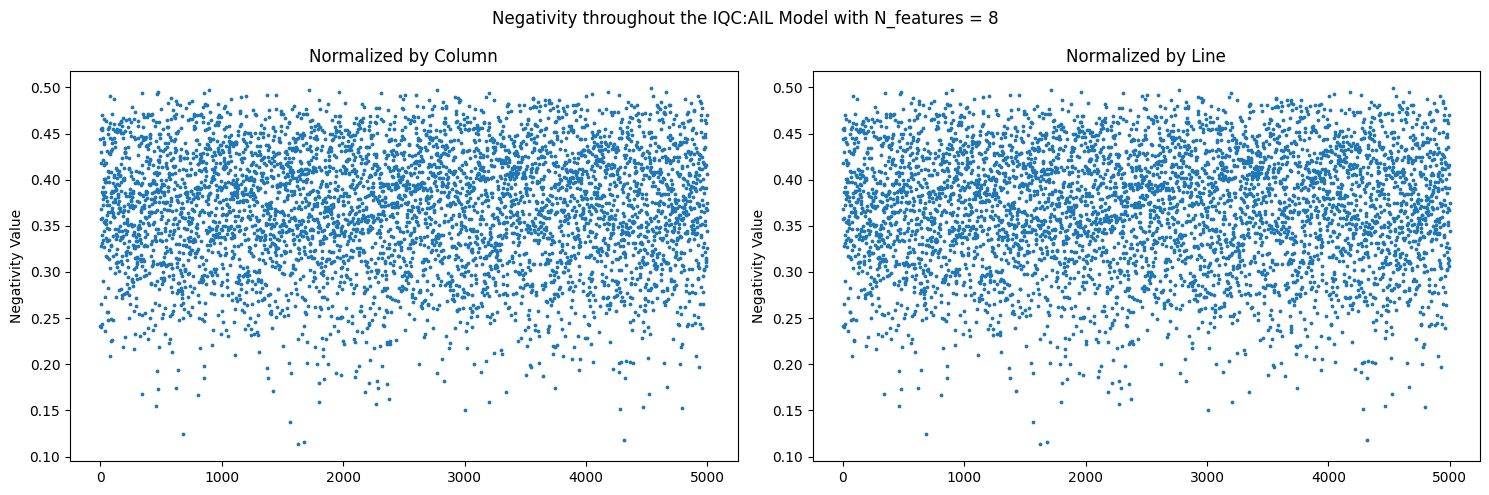

In [24]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig,ax=plt.subplots(1,2,figsize=(15,5))

num_neg=[]
for i in range(N_SAMPLES):
    num_neg.append(i)

ax[0].scatter(num_neg,neg_col8_ail, marker='.', s=12)
ax[0].set_ylabel('Negativity Value')
ax[0].set_title('Normalized by Column')

plt.suptitle(f'Negativity throughout the IQC:AIL Model with N_features = {N_features}')


ax[1].scatter(num_neg,neg_lin8_ail, marker='.', s=12)
ax[1].set_ylabel('Negativity Value')
ax[1].set_title('Normalized by Line')
plt.savefig(fold+f'/Negativity_NF{N_features}_IQC_AIL.svg')

### IQC, NF = 2

In [25]:
fold = 'NF2_IQC'

# Verifique se o diretório existe e o crie, se não existir
if not os.path.exists(fold):
    os.makedirs(fold)

In [26]:
# IQC, NF2
N_features=2
counter=0
X_df=np.random.rand(N_SAMPLES,N_features)
w_df=np.random.rand(N_SAMPLES,N_features)
N_QUBITS=math.ceil(np.log2(N_features)+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]
X_df_iqc_coluna=normalize_iqc_ail(X_df, normalize_col=True, normalize_lin=False)
X_df_iqc_linha=normalize_iqc_ail(X_df,normalize_col=False,normalize_lin=True)
u3_col,neg_col2_iqc=esfera_bloch_IQC(X_df_iqc_coluna,w_df,'coluna',QUBITS, N_QUBITS,N_features,counter,fold)
u3_lin,neg_lin2_iqc=esfera_bloch_IQC(X_df_iqc_linha,w_df,'linha',QUBITS, N_QUBITS,N_features,counter,fold)


c:\Users\pichau\.conda\envs\qiskit\Lib\site-packages\qutip\bloch.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.canvas.draw()
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\3535837406.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  bb.savefig(fname=fold+f'/Bloch_geral_NF{N_features}_IQC_{norma}.svg')


In [27]:
lens=[]
for i in range(len(u3_col)):
    lens.append(len(u3_col[i]))

unique_G_col=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_col=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_col.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_col.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_col.append(to_binning[1][i]//100)

lens=[]
for i in range(len(u3_lin)):
    lens.append(len(u3_lin[i]))

unique_G_lin=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_lin=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_lin.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_lin.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_lin.append(to_binning[1][i]//100)

listao2_col=dividir_por_tamanho(u3_col) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
listao2_lin=dividir_por_tamanho(u3_lin) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
neg_col2_iqc=np.array(neg_col2_iqc)
neg_lin2_iqc=np.array(neg_lin2_iqc)

In [28]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_col)):
    for i in range(unique_G_col[j]):
        array=np.array(listao2_col[unique_G_col[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_col[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_col[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_col[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_col_G{unique_G_col[j]}_IQC.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2196337714.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2196337714.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2196337714.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [29]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_lin)):
    for i in range(unique_G_lin[j]):
        array=np.array(listao2_lin[unique_G_lin[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_lin[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_lin_G{unique_G_lin[j]}_IQC.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\4205197705.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\4205197705.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\4205197705.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


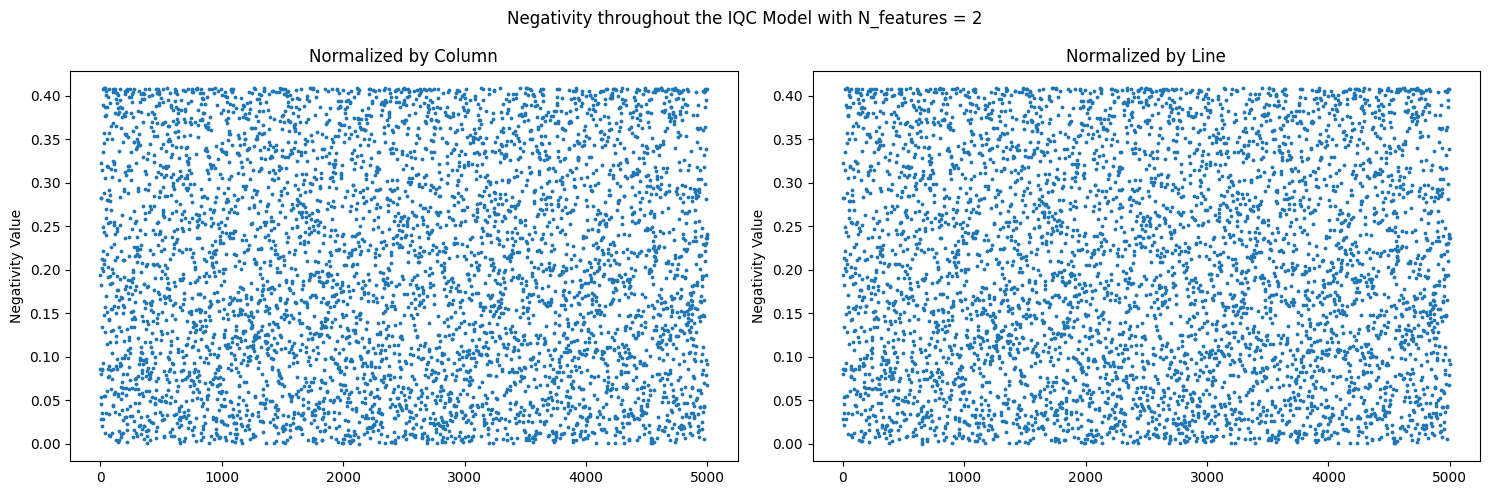

In [30]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig,ax=plt.subplots(1,2,figsize=(15,5))

num_neg=[]
for i in range(N_SAMPLES):
    num_neg.append(i)

ax[0].scatter(num_neg,neg_col2_iqc, marker='.', s=12)
ax[0].set_ylabel('Negativity Value')
ax[0].set_title('Normalized by Column')

plt.suptitle(f'Negativity throughout the IQC Model with N_features = {N_features}')


ax[1].scatter(num_neg,neg_lin2_iqc, marker='.', s=12)
ax[1].set_ylabel('Negativity Value')
ax[1].set_title('Normalized by Line')
plt.savefig(fold+f'/Negativity_NF{N_features}_IQC.svg')

### IQC, NF = 4

In [31]:
fold = 'NF4_IQC'

# Verifique se o diretório existe e o crie, se não existir
if not os.path.exists(fold):
    os.makedirs(fold)

In [32]:
# IQC, NF4
N_features=4
counter=0
X_df=np.random.rand(N_SAMPLES,N_features)
w_df=np.random.rand(N_SAMPLES,N_features)
N_QUBITS=math.ceil(np.log2(N_features)+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]
X_df_iqc_coluna=normalize_iqc_ail(X_df, normalize_col=True, normalize_lin=False)
X_df_iqc_linha=normalize_iqc_ail(X_df,normalize_col=False,normalize_lin=True)
u3_col,neg_col4_iqc=esfera_bloch_IQC(X_df_iqc_coluna,w_df,'coluna',QUBITS, N_QUBITS,N_features,counter,fold)
u3_lin,neg_lin4_iqc=esfera_bloch_IQC(X_df_iqc_linha,w_df,'linha',QUBITS, N_QUBITS,N_features,counter,fold)


c:\Users\pichau\.conda\envs\qiskit\Lib\site-packages\qutip\bloch.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.canvas.draw()
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\3535837406.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  bb.savefig(fname=fold+f'/Bloch_geral_NF{N_features}_IQC_{norma}.svg')


In [33]:
lens=[]
for i in range(len(u3_col)):
    lens.append(len(u3_col[i]))

unique_G_col=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_col=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_col.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_col.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_col.append(to_binning[1][i]//100)

lens=[]
for i in range(len(u3_lin)):
    lens.append(len(u3_lin[i]))

unique_G_lin=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_lin=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_lin.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_lin.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_lin.append(to_binning[1][i]//100)

listao4_col=dividir_por_tamanho(u3_col) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
listao4_lin=dividir_por_tamanho(u3_lin) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
neg_col4_iqc=np.array(neg_col4_iqc)
neg_lin4_iqc=np.array(neg_lin4_iqc)

In [34]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_col)):
    for i in range(unique_G_col[j]):
        array=np.array(listao4_col[unique_G_col[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_col[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_col[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_col[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_col_G{unique_G_col[j]}_IQC.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2773239879.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2773239879.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2773239879.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [35]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_lin)):
    for i in range(unique_G_lin[j]):
        array=np.array(listao4_lin[unique_G_lin[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_lin[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_lin_G{unique_G_lin[j]}_IQC.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\1018768609.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\1018768609.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\1018768609.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


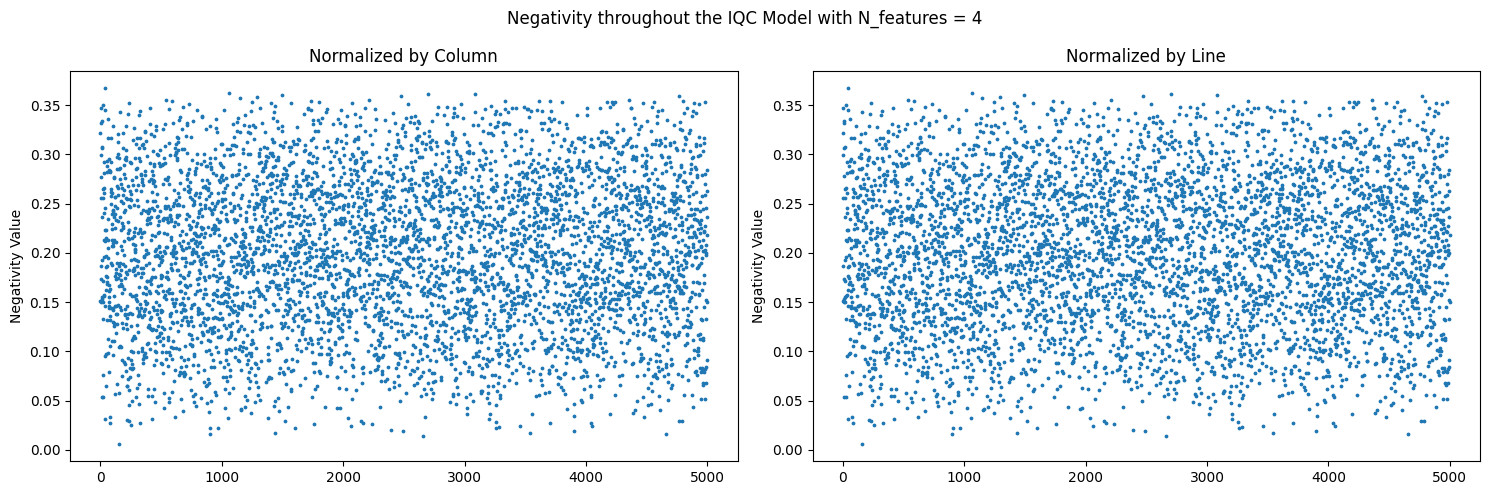

In [36]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig,ax=plt.subplots(1,2,figsize=(15,5))

num_neg=[]
for i in range(N_SAMPLES):
    num_neg.append(i)

ax[0].scatter(num_neg,neg_col4_iqc, marker='.', s=12)
ax[0].set_ylabel('Negativity Value')
ax[0].set_title('Normalized by Column')

plt.suptitle(f'Negativity throughout the IQC Model with N_features = {N_features}')


ax[1].scatter(num_neg,neg_lin4_iqc, marker='.', s=12)
ax[1].set_ylabel('Negativity Value')
ax[1].set_title('Normalized by Line')
plt.savefig(fold+f'/Negativity_NF{N_features}_IQC.svg')

### IQC, NF = 8

In [37]:
fold = 'NF8_IQC'

# Verifique se o diretório existe e o crie, se não existir
if not os.path.exists(fold):
    os.makedirs(fold)

In [38]:
# IQC, NF8
N_features=8
counter=0
X_df=np.random.rand(N_SAMPLES,N_features)
w_df=np.random.rand(N_SAMPLES,N_features)
N_QUBITS=math.ceil(np.log2(N_features)+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]
X_df_iqc_coluna=normalize_iqc_ail(X_df, normalize_col=True, normalize_lin=False)
X_df_iqc_linha=normalize_iqc_ail(X_df,normalize_col=False,normalize_lin=True)
u3_col,neg_col8_iqc=esfera_bloch_IQC(X_df_iqc_coluna,w_df,'coluna',QUBITS, N_QUBITS,N_features,counter,fold)
u3_lin,neg_lin8_iqc=esfera_bloch_IQC(X_df_iqc_linha,w_df,'linha',QUBITS, N_QUBITS,N_features,counter,fold)


c:\Users\pichau\.conda\envs\qiskit\Lib\site-packages\qutip\bloch.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.canvas.draw()
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\3535837406.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  bb.savefig(fname=fold+f'/Bloch_geral_NF{N_features}_IQC_{norma}.svg')


In [39]:
lens=[]
for i in range(len(u3_col)):
    lens.append(len(u3_col[i]))

unique_G_col=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_col=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_col.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_col.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_col.append(to_binning[1][i]//100)

lens=[]
for i in range(len(u3_lin)):
    lens.append(len(u3_lin[i]))

unique_G_lin=np.unique(lens)

to_binning=np.unique_counts(lens)
bin_sizes_lin=[]
for i in range(len(to_binning[0])):
    if to_binning[1][i]<=100:
        bin_sizes_lin.append(to_binning[1][i])
    elif to_binning[1][i]<=1000 and to_binning[1][i]>100:
        bin_sizes_lin.append(to_binning[1][i]//10)
    elif to_binning[1][i]>1000:
        bin_sizes_lin.append(to_binning[1][i]//100)

listao8_col=dividir_por_tamanho(u3_col) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
listao8_lin=dividir_por_tamanho(u3_lin) # lista[G size index][tqc index][gate index][params] --> lista[int(np.unique[j])][:][i][0 or 1 or 2]
neg_col8_iqc=np.array(neg_col8_iqc)
neg_lin8_iqc=np.array(neg_lin8_iqc)

In [40]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_col)):
    for i in range(unique_G_col[j]):
        array=np.array(listao8_col[unique_G_col[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_col[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_col[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_col[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_col_G{unique_G_col[j]}_IQC.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\3976687716.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\3976687716.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\3976687716.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [41]:
unique_G_lin

array([61, 69, 75, 77, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92,
       93, 94, 95])

In [42]:

lista2=[]
for j in range(len(unique_G_lin)):
    lista=[]
    for i in range(unique_G_lin[j]):
        lista.append(i)
    lista2.append(lista)

In [43]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

for j in range(len(unique_G_lin)):
    for i in range(unique_G_lin[j]):
        array=np.array(listao8_lin[unique_G_lin[j]]) # array[tqc index,gates index,parameters index]
        fig,ax=plt.subplots(1,3,figsize=(15,5))
        ax[0].hist(array[:,i,0]/np.pi,label=labels[0],color=colors[0], bins=bin_sizes_lin[j],edgecolor='black') # lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[0].set_xlabel(f'Factor of $\pi$')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        ax[0].grid(linestyle='dashed')

        ax[1].hist(array[:,i,1]/np.pi,label=labels[1],color=colors[1], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[1].set_xlabel(f'Factor of $\pi$')
        ax[1].set_ylabel('Frequency')
        ax[1].legend()
        ax[1].grid(linestyle='dashed')

        ax[2].hist(array[:,i,2]/np.pi,label=labels[2],color=colors[2], bins=bin_sizes_lin[j],edgecolor='black') #lista[int(np.unique[j])][:][i][0 or 1 or 2]
        ax[2].set_xlabel(f'Factor of $\pi$')
        ax[2].set_ylabel('Frequency')
        ax[2].legend()
        ax[2].grid(linestyle='dashed')

        plt.savefig(fold+f'/histogram_NF{N_features}_gate{i}_lin_G{unique_G_lin[j]}_IQC.svg')
        plt.close(fig)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2003829143.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2003829143.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13360\2003829143.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


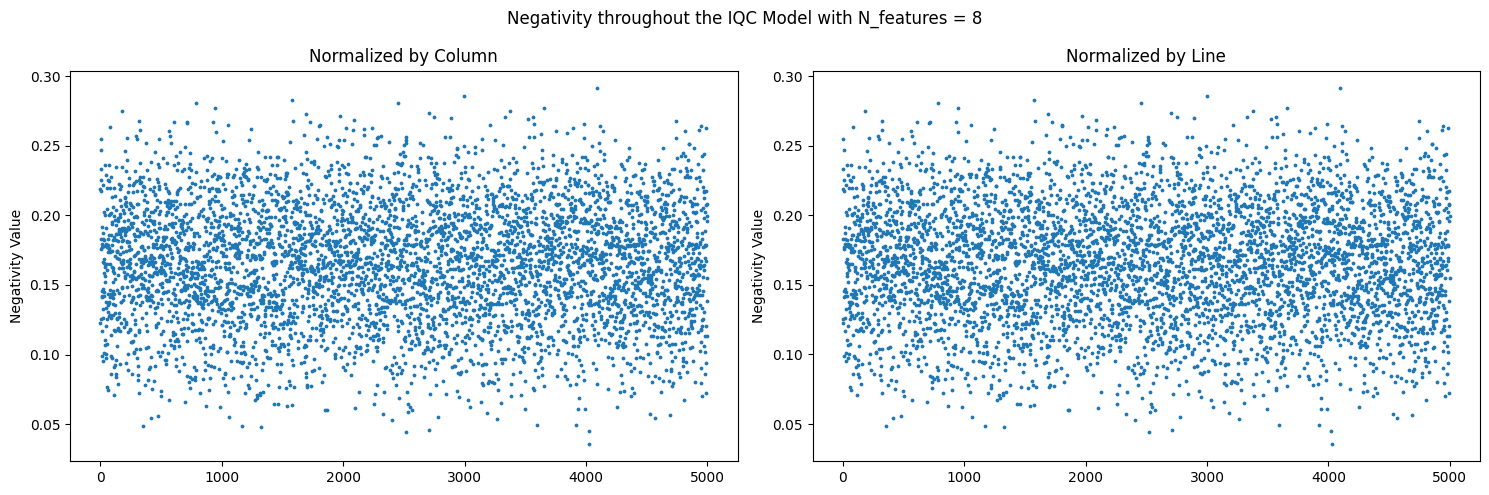

In [44]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig,ax=plt.subplots(1,2,figsize=(15,5))

num_neg=[]
for i in range(N_SAMPLES):
    num_neg.append(i)

ax[0].scatter(num_neg,neg_col8_iqc, marker='.', s=12)
ax[0].set_ylabel('Negativity Value')
ax[0].set_title('Normalized by Column')

plt.suptitle(f'Negativity throughout the IQC Model with N_features = {N_features}')


ax[1].scatter(num_neg,neg_lin8_iqc, marker='.', s=12)
ax[1].set_ylabel('Negativity Value')
ax[1].set_title('Normalized by Line')
plt.savefig(fold+f'/Negativity_NF{N_features}_IQC.svg')